In [45]:
import arxiv
client =arxiv.Client()
def collect_arxiv_papers(catagory:str, max_results=100):
  search=arxiv.Search(
      query=f"cat:{catagory}",
      max_results=max_results,
      sort_by=arxiv.SortCriterion.LastUpdatedDate
  )
  papers=[]
  for result in client.results(search):
    paper={
        'title':result.title,
        'authors':[author.name for author in result.authors],
        'abstract':result.summary,
        'published':result.published,
        'catagory':catagory,
        'arxiv_id':result.entry_id.split('/')[-1]
    }
    papers.append(paper)
  return papers

catagories=[
    ('cs.LG', 'Machine Learning'),
    ('cs.CV', 'Computer Vision'),
    ('cs.CL', 'Computational Linguistics'),
    ('cs.DB', 'Databases'),
    ('cs.SE', 'Software Engineering'),
    ('stat.ML', 'Statistics - Machine Learning'),
  ]
all_papers=[]
for catagory_code, catagory_name in catagories:
  print(f"printing papers from {catagory_name} ({catagory_code})")
  papers=collect_arxiv_papers(catagory_code, max_results=100)
  all_papers.extend(papers)
  print(f"collected {len(papers)} papers")
### Let's examine the first paper from each category
separator = "=" * 80
print(f"\n{separator}", "SAMPLE PAPERS (one from each category)", f"{separator}", sep="\n")
for i, (_, category_name) in enumerate(catagories):
    paper = all_papers[i * 100]
    print(f"\n{category_name}:")
    print(f"  Title: {paper['title']}")
    print(f"  Abstract (first 150 chars): {paper['abstract'][:150]}...")

printing papers from Machine Learning (cs.LG)
collected 100 papers
printing papers from Computer Vision (cs.CV)
collected 100 papers
printing papers from Computational Linguistics (cs.CL)
collected 100 papers
printing papers from Databases (cs.DB)
collected 100 papers
printing papers from Software Engineering (cs.SE)
collected 100 papers
printing papers from Statistics - Machine Learning (stat.ML)
collected 100 papers

SAMPLE PAPERS (one from each category)

Machine Learning:
  Title: Accurate and scalable exchange-correlation with deep learning
  Abstract (first 150 chars): Density Functional Theory (DFT) underpins much of modern computational chemistry and materials science. Yet, the reliability of DFT-derived prediction...

Computer Vision:
  Title: Tstars-Tryon 1.0: Robust and Realistic Virtual Try-On for Diverse Fashion Items
  Abstract (first 150 chars): Recent advances in image generation and editing have opened new opportunities for virtual try-on. However, existing methods sti

In [46]:
import pandas as pd
#channging the above dataset into frame for easier visualization
df=pd.DataFrame(all_papers)
df.head()

,title,authors,abstract,published,catagory,arxiv_id
0,Accurate and scalable exchange-correlation wit...,"[Giulia Luise, Chin-Wei Huang, Thijs Vogels, D...",Density Functional Theory (DFT) underpins much...,2025-06-17 15:56:56+00:00,cs.LG,2506.14665v6
1,Generalization at the Edge of Stability,"[Mario Tuci, Caner Korkmaz, Umut Şimşekli, Tol...",Training modern neural networks often relies o...,2026-04-21 17:59:02+00:00,cs.LG,2604.19740v1
2,Phase Transitions in the Fluctuations of Funct...,"[Simmaco Di Lillo, Leonardo Maini, Domenico Ma...",We establish central and non-central limit the...,2026-04-21 17:58:39+00:00,cs.LG,2604.19738v1
3,Safe Continual Reinforcement Learning in Non-s...,"[Austin Coursey, Abel Diaz-Gonzalez, Marcos Qu...",Reinforcement learning (RL) offers a compellin...,2026-04-21 17:58:32+00:00,cs.LG,2604.19737v1
4,Tackling multiphysics problems via finite elem...,"[Yusuke Yamazaki, Reza Najian Asl, Markus Apel...",This work presents a finite element-guided phy...,2026-03-02 03:52:51+00:00,cs.LG,2603.01420v3


In [3]:
len(df)

500

In [47]:
print(f"Papers with abstracts: {df['abstract'].notna().sum()}")

Papers with abstracts: 600


In [48]:
missing_abstracts = df['abstract'].isna().sum()
print(missing_abstracts)

0


In [49]:
df['abstract_length'] = df['abstract'].str.len()

In [52]:
df.head()

,title,authors,abstract,published,catagory,arxiv_id,abstract_length
0,Accurate and scalable exchange-correlation wit...,"[Giulia Luise, Chin-Wei Huang, Thijs Vogels, D...",Density Functional Theory (DFT) underpins much...,2025-06-17 15:56:56+00:00,cs.LG,2506.14665v6,1458
1,Generalization at the Edge of Stability,"[Mario Tuci, Caner Korkmaz, Umut Şimşekli, Tol...",Training modern neural networks often relies o...,2026-04-21 17:59:02+00:00,cs.LG,2604.19740v1,1106
2,Phase Transitions in the Fluctuations of Funct...,"[Simmaco Di Lillo, Leonardo Maini, Domenico Ma...",We establish central and non-central limit the...,2026-04-21 17:58:39+00:00,cs.LG,2604.19738v1,932
3,Safe Continual Reinforcement Learning in Non-s...,"[Austin Coursey, Abel Diaz-Gonzalez, Marcos Qu...",Reinforcement learning (RL) offers a compellin...,2026-04-21 17:58:32+00:00,cs.LG,2604.19737v1,1711
4,Tackling multiphysics problems via finite elem...,"[Yusuke Yamazaki, Reza Najian Asl, Markus Apel...",This work presents a finite element-guided phy...,2026-03-02 03:52:51+00:00,cs.LG,2603.01420v3,1916


In [53]:
df.tail()

,title,authors,abstract,published,catagory,arxiv_id,abstract_length
595,Neighbor Embedding for High-Dimensional Sparse...,"[Noga Mudrik, Adam S. Charles]","Across many scientific fields, measurements of...",2026-04-18 09:31:08+00:00,stat.ML,2604.16932v1,1432
596,Covariance-Based Structural Equation Modeling ...,"[Hiroki Hasegawa, Aoba Tamura, Yukihiko Okada]",Factor-based Structural Equation Modeling (SEM...,2026-04-18 08:03:34+00:00,stat.ML,2604.16894v1,827
597,A Ridge Too Far: Correcting Over-Shrinkage via...,"[Dongseok Kim, Gisung Oh]",Conventional regularization is designed to con...,2025-08-24 15:34:17+00:00,stat.ML,2508.17412v4,925
598,Extraction of informative statistical features...,"[Victor Korolev, Mikhail Ivanov, Tatiana Kukan...","In this paper, we consider the problem of extr...",2026-04-18 06:31:21+00:00,stat.ML,2604.16865v1,1742
599,Bayesian Neural Networks: An Introduction and ...,"[Ethan Goan, Clinton Fookes]",Neural Networks (NNs) have provided state-of-t...,2020-06-22 06:30:15+00:00,stat.ML,2006.12024v3,636


In [54]:
len(df[df['abstract_length']<100])

0

In [55]:
print(f"Average abstract length: {df['abstract_length'].mean():.0f} characters")

Average abstract length: 1361 characters


In [56]:
print(df['catagory'].value_counts().sort_index())

catagory
cs.CL      100
cs.CV      100
cs.DB      100
cs.LG      100
cs.SE      100
stat.ML    100
Name: count, dtype: int64


In [12]:
separator = "=" * 80
print(f"\n{separator}", "FIRST 3 PAPERS IN CLEANED DATASET", f"{separator}", sep="\n")
for idx, row in df.head(3).iterrows():
    print(f"\n{idx+1}. {row['title']}")
    print(f"   Catagory: {row['catagory']}")
    print(f"   Abstract length: {row['abstract_length']} characters")


FIRST 3 PAPERS IN CLEANED DATASET

1. MathNet: a Global Multimodal Benchmark for Mathematical Reasoning and Retrieval
   Catagory: cs.LG
   Abstract length: 1553 characters

2. Sessa: Selective State Space Attention
   Catagory: cs.LG
   Abstract length: 1653 characters

3. Bounded Ratio Reinforcement Learning
   Catagory: cs.LG
   Abstract length: 1504 characters


In [57]:
from sentence_transformers import SentenceTransformer
import numpy as np
import time

In [58]:
print("Loading all-MiniLM-L6-v2 model...")
small_model=SentenceTransformer('all-MiniLM-L6-v2')
abstracts=df['abstract'].tolist()
print(f"generating embeding for {len(abstracts)} papers")
start=time.time()
embeddings_small=small_model.encode(
    abstracts,
    show_progress_bar=True,
    batch_size=32
)
elapsed_time=time.time() - start
print(f"\nCompleted in {elapsed_time:.2f} seconds")
print(f"Embedding shape: {embeddings_small.shape}")



Loading all-MiniLM-L6-v2 model...


Loading weights:   0%|          | 0/103 [00:01<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     | Details
------------------------+------------+--------
embeddings.position_ids | UNEXPECTED |        

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generating embeding for 600 papers


Batches:   0%|          | 0/19 [00:00<?, ?it/s]


Completed in 74.31 seconds
Embedding shape: (600, 384)


In [59]:
print(f"Each abstract is now a {embeddings_small.shape[1]}-dimensional vector")

Each abstract is now a 384-dimensional vector


In [60]:
print(f"Average time per abstract: {elapsed_time/len(abstracts):.3f} seconds")

Average time per abstract: 0.124 seconds


In [61]:
df['embedding_minilm'] = list(embeddings_small)

In [62]:
df.head()

,title,authors,abstract,published,catagory,arxiv_id,abstract_length,embedding_minilm
0,Accurate and scalable exchange-correlation wit...,"[Giulia Luise, Chin-Wei Huang, Thijs Vogels, D...",Density Functional Theory (DFT) underpins much...,2025-06-17 15:56:56+00:00,cs.LG,2506.14665v6,1458,"[-0.11262365, -0.10990522, 0.054898735, 0.1194..."
1,Generalization at the Edge of Stability,"[Mario Tuci, Caner Korkmaz, Umut Şimşekli, Tol...",Training modern neural networks often relies o...,2026-04-21 17:59:02+00:00,cs.LG,2604.19740v1,1106,"[-0.021548355, -0.11020677, 0.039979618, 0.022..."
2,Phase Transitions in the Fluctuations of Funct...,"[Simmaco Di Lillo, Leonardo Maini, Domenico Ma...",We establish central and non-central limit the...,2026-04-21 17:58:39+00:00,cs.LG,2604.19738v1,932,"[-0.05240786, -0.08802482, 0.05230844, -0.0400..."
3,Safe Continual Reinforcement Learning in Non-s...,"[Austin Coursey, Abel Diaz-Gonzalez, Marcos Qu...",Reinforcement learning (RL) offers a compellin...,2026-04-21 17:58:32+00:00,cs.LG,2604.19737v1,1711,"[-0.02924505, -0.031961568, -0.019948972, 0.06..."
4,Tackling multiphysics problems via finite elem...,"[Yusuke Yamazaki, Reza Najian Asl, Markus Apel...",This work presents a finite element-guided phy...,2026-03-02 03:52:51+00:00,cs.LG,2603.01420v3,1916,"[-0.04790274, 0.0045507476, 0.06279659, 0.0368..."


In [63]:
print("\nLoading all-mpnet-base-v2 model...")
model_large = SentenceTransformer('all-mpnet-base-v2')

print("Generating embeddings with larger model...")
start_time = time.time()
embeddings_large = model_large.encode(
    abstracts,
    show_progress_bar=True,
    batch_size=32
)
elapsed_time = time.time() - start_time
print(f"\nCompleted in {elapsed_time:.2f} seconds")
print(f"Embedding shape: {embeddings_large.shape}")
print(f"Each abstract is now a {embeddings_large.shape[1]}-dimensional vector")
print(f"Average time per abstract: {elapsed_time/len(abstracts):.3f} seconds")

### Add these embeddings to our DataFrame too
df['embedding_mpnet'] = list(embeddings_large)


Loading all-mpnet-base-v2 model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     | Details
------------------------+------------+--------
embeddings.position_ids | UNEXPECTED |        

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating embeddings with larger model...


Batches:   0%|          | 0/19 [00:00<?, ?it/s]


Completed in 403.41 seconds
Embedding shape: (600, 768)
Each abstract is now a 768-dimensional vector
Average time per abstract: 0.672 seconds


In [65]:
df.head()

,title,authors,abstract,published,catagory,arxiv_id,abstract_length,embedding_minilm,embedding_mpnet
0,Accurate and scalable exchange-correlation wit...,"[Giulia Luise, Chin-Wei Huang, Thijs Vogels, D...",Density Functional Theory (DFT) underpins much...,2025-06-17 15:56:56+00:00,cs.LG,2506.14665v6,1458,"[-0.11262365, -0.10990522, 0.054898735, 0.1194...","[-0.015232995, 0.07971689, -0.005363807, 0.029..."
1,Generalization at the Edge of Stability,"[Mario Tuci, Caner Korkmaz, Umut Şimşekli, Tol...",Training modern neural networks often relies o...,2026-04-21 17:59:02+00:00,cs.LG,2604.19740v1,1106,"[-0.021548355, -0.11020677, 0.039979618, 0.022...","[-0.06894975, -0.0013265202, -0.023594018, 0.0..."
2,Phase Transitions in the Fluctuations of Funct...,"[Simmaco Di Lillo, Leonardo Maini, Domenico Ma...",We establish central and non-central limit the...,2026-04-21 17:58:39+00:00,cs.LG,2604.19738v1,932,"[-0.05240786, -0.08802482, 0.05230844, -0.0400...","[-0.034121223, 0.017960884, -0.04844394, 0.029..."
3,Safe Continual Reinforcement Learning in Non-s...,"[Austin Coursey, Abel Diaz-Gonzalez, Marcos Qu...",Reinforcement learning (RL) offers a compellin...,2026-04-21 17:58:32+00:00,cs.LG,2604.19737v1,1711,"[-0.02924505, -0.031961568, -0.019948972, 0.06...","[-0.021283355, 0.04780567, 0.011241665, -0.001..."
4,Tackling multiphysics problems via finite elem...,"[Yusuke Yamazaki, Reza Najian Asl, Markus Apel...",This work presents a finite element-guided phy...,2026-03-02 03:52:51+00:00,cs.LG,2603.01420v3,1916,"[-0.04790274, 0.0045507476, 0.06279659, 0.0368...","[-0.0416405, 0.07598719, -0.021002354, 0.06442..."


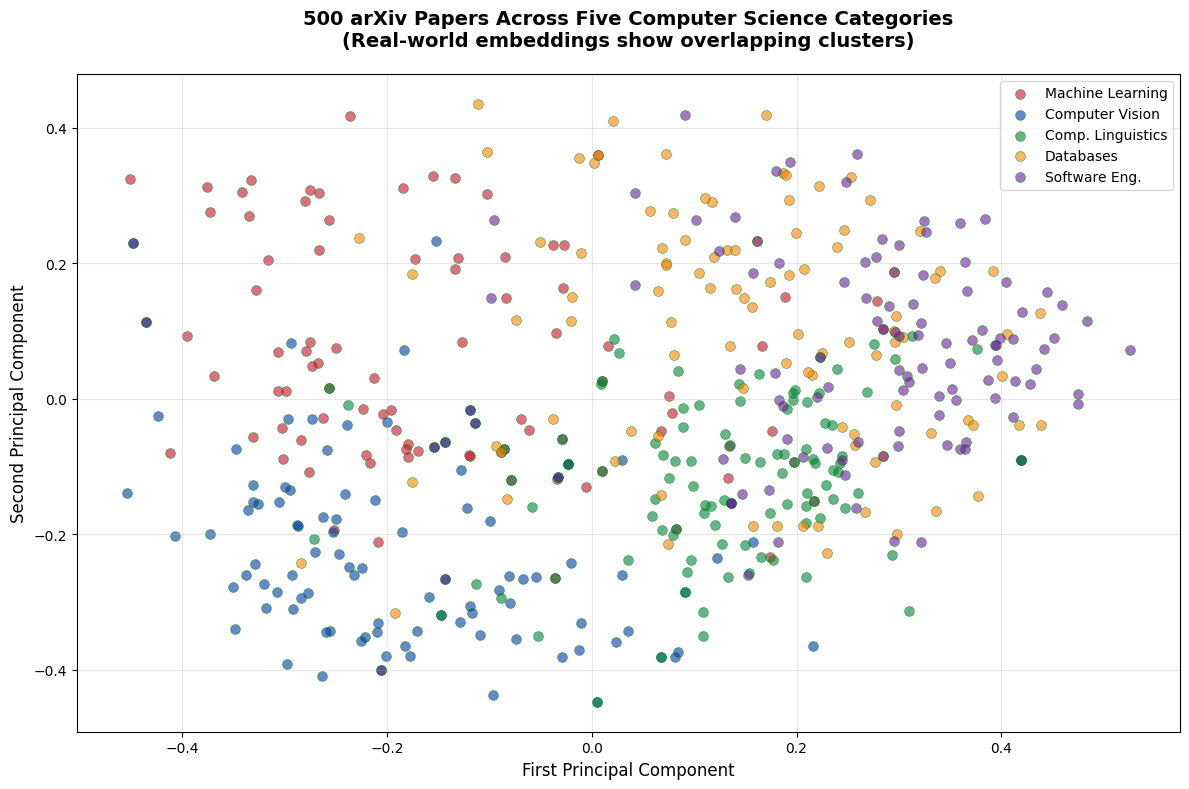

In [72]:
import sklearn
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
embeddings_2d=pca.fit_transform(embeddings_small)
plt.figure(figsize=(12, 8))
colors = ['#C8102E', '#003DA5', '#00843D', '#FF8200', '#6A1B9A']
category_names = ['Machine Learning', 'Computer Vision', 'Comp. Linguistics', 'Databases', 'Software Eng.']
category_codes = ['cs.LG', 'cs.CV', 'cs.CL', 'cs.DB', 'cs.SE']
for i, (cat_code, cat_name, color) in enumerate(zip(category_codes, category_names, colors)):
    mask = df['catagory'] == cat_code
    cat_embeddings = embeddings_2d[mask]
    plt.scatter(cat_embeddings[:, 0], cat_embeddings[:, 1],
                c=color, label=cat_name, s=50, alpha=0.6, edgecolors='green', linewidth=0.5)
plt.xlabel('First Principal Component', fontsize=12)
plt.ylabel('Second Principal Component', fontsize=12)
plt.title('500 arXiv Papers Across Five Computer Science Categories\n(Real-world embeddings show overlapping clusters)',
          fontsize=14, fontweight='bold', pad=20)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

visualization of "stat_ml" with the other papers, and it clrealy shows that it over lap with machine learning

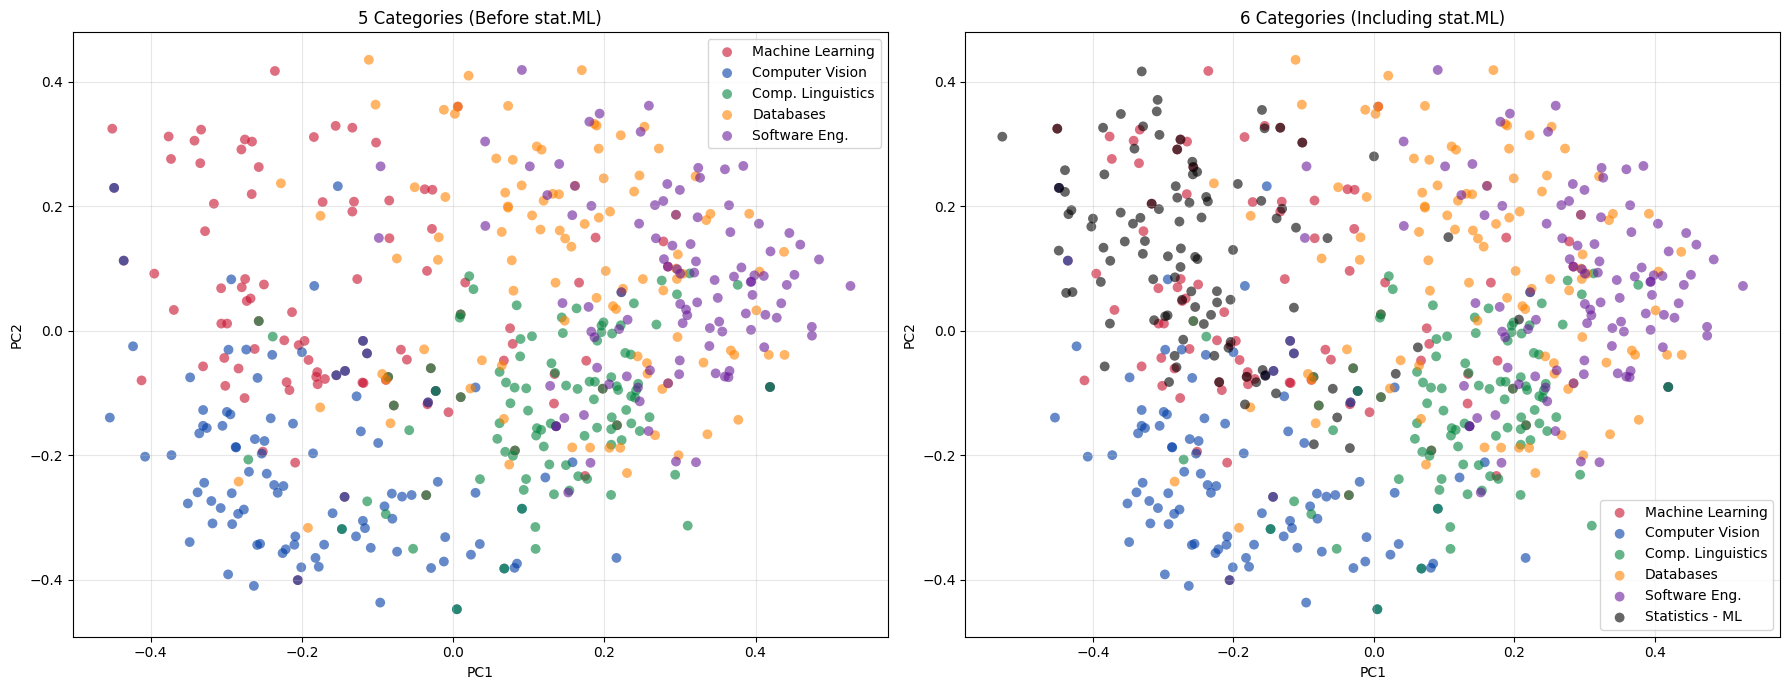

In [73]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# --- PCA ---
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings_small)

# --- Setup figure with 2 plots ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

colors = ['#C8102E', '#003DA5', '#00843D', '#FF8200', '#6A1B9A', "#000000"]

category_names_5 = [
    'Machine Learning',
    'Computer Vision',
    'Comp. Linguistics',
    'Databases',
    'Software Eng.'
]

category_names_6 = category_names_5 + ['Statistics - ML']

category_codes_5 = ['cs.LG', 'cs.CV', 'cs.CL', 'cs.DB', 'cs.SE']
category_codes_6 = category_codes_5 + ['stat.ML']

# =========================
# LEFT PLOT (5 categories)
# =========================
for cat_code, cat_name, color in zip(category_codes_5, category_names_5, colors[:5]):
    mask = df['catagory'] == cat_code
    cat_embeddings = embeddings_2d[mask]

    axes[0].scatter(
        cat_embeddings[:, 0],
        cat_embeddings[:, 1],
        c=color,
        label=cat_name,
        s=50,
        alpha=0.6,
        edgecolors='none'
    )

axes[0].set_title("5 Categories (Before stat.ML)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend()
axes[0].grid(alpha=0.3)

# =========================
# RIGHT PLOT (6 categories)
# =========================
for cat_code, cat_name, color in zip(category_codes_6, category_names_6, colors):
    mask = df['catagory'] == cat_code
    cat_embeddings = embeddings_2d[mask]

    axes[1].scatter(
        cat_embeddings[:, 0],
        cat_embeddings[:, 1],
        c=color,
        label=cat_name,
        s=50,
        alpha=0.6,
        edgecolors='none'
    )

axes[1].set_title("6 Categories (Including stat.ML)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend()
axes[1].grid(alpha=0.3)

# --- Final layout ---
plt.tight_layout()
plt.show()


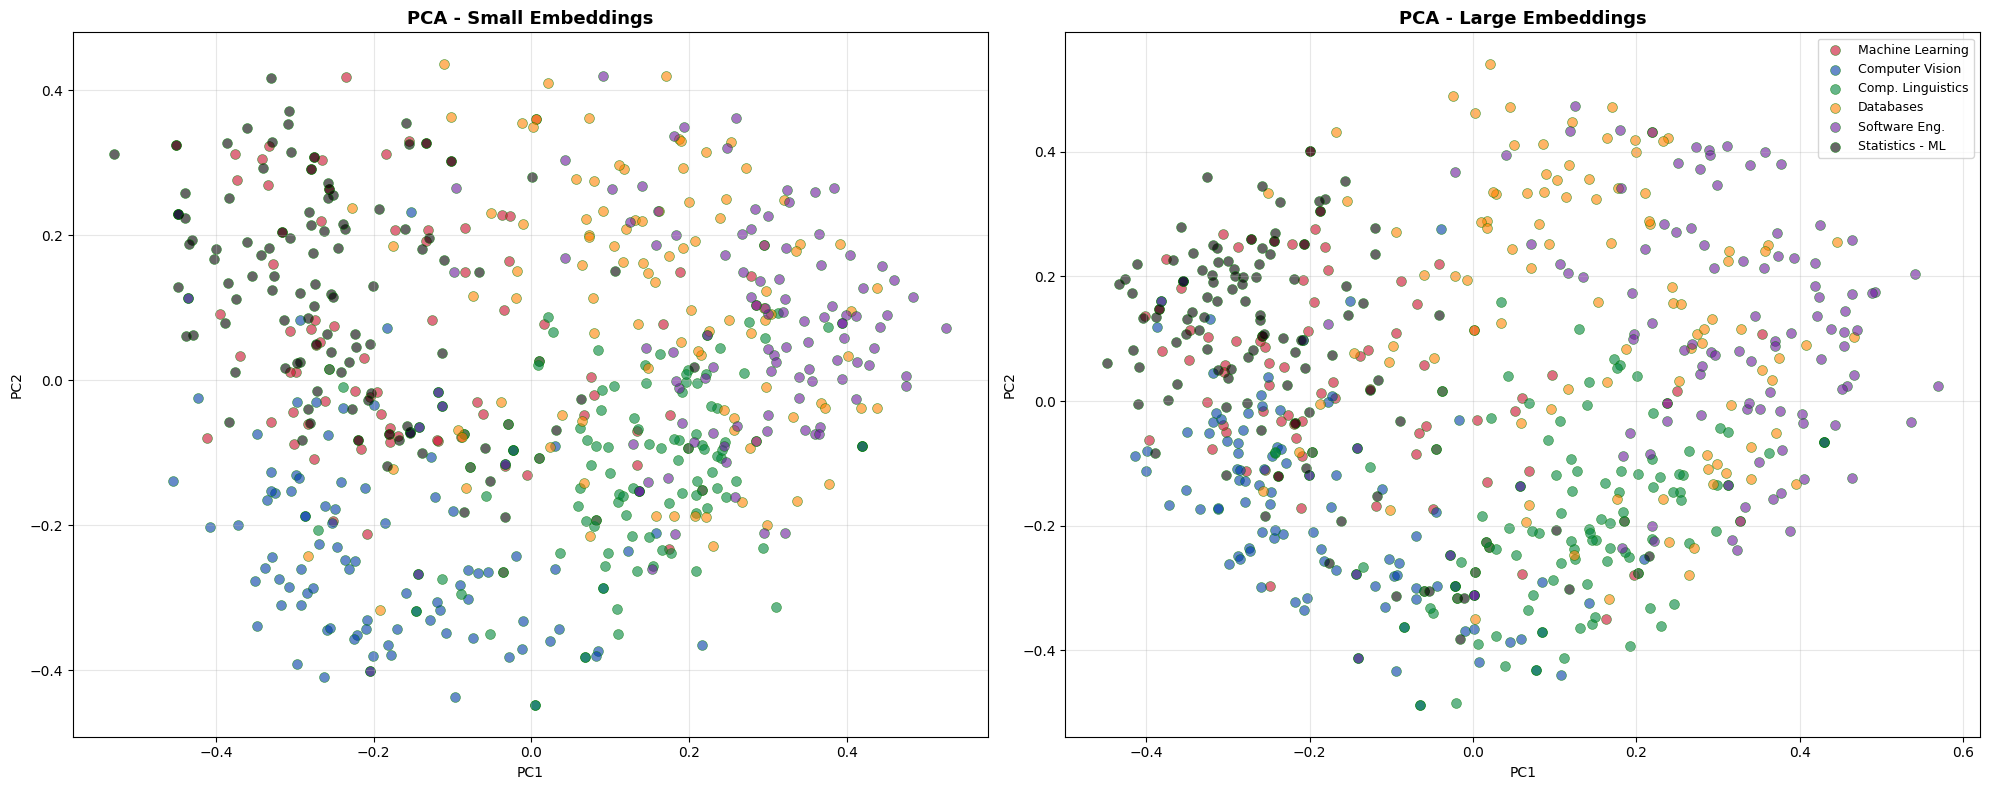

In [75]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# --- PCA for small embeddings ---
pca_small = PCA(n_components=2)
embeddings_small_2d = pca_small.fit_transform(embeddings_small)

# --- PCA for large embeddings ---
pca_large = PCA(n_components=2)
embeddings_large_2d = pca_large.fit_transform(embeddings_large)

# Setup plot
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

colors = ['#C8102E', '#003DA5', '#00843D', '#FF8200', '#6A1B9A', '#000000']
category_names = ['Machine Learning', 'Computer Vision', 'Comp. Linguistics', 'Databases', 'Software Eng.', 'Statistics - ML']
category_codes = ['cs.LG', 'cs.CV', 'cs.CL', 'cs.DB', 'cs.SE', 'stat.ML']

# --- helper function ---
def plot_embeddings(ax, embeddings_2d, title):
    for cat_code, cat_name, color in zip(category_codes, category_names, colors):
        mask = df['catagory'] == cat_code  # fix typo: category
        cat_embeddings = embeddings_2d[mask]

        ax.scatter(
            cat_embeddings[:, 0],
            cat_embeddings[:, 1],
            c=color,
            label=cat_name,
            s=50,
            alpha=0.6,
            edgecolors='green',
            linewidth=0.5
        )

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.grid(True, alpha=0.3)

# --- left plot: small ---
plot_embeddings(axes[0], embeddings_small_2d, "PCA - Small Embeddings")

# --- right plot: large ---
plot_embeddings(axes[1], embeddings_large_2d, "PCA - Large Embeddings")

axes[1].legend(loc='best', fontsize=9)

plt.tight_layout()
plt.show()

In [76]:
from api_key import co

In [78]:
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder

In [80]:
le = LabelEncoder()
labels = le.fit_transform(df['catagory'])

In [81]:
score = silhouette_score(embeddings_small, labels)

print("Silhouette Score:", score)

Silhouette Score: 0.02268550544977188


In [82]:
mask_5 = df['catagory'] != 'stat.ML'

score_5 = silhouette_score(
    embeddings_small[mask_5],
    labels[mask_5]
)

print("Silhouette (5 categories):", score_5)

Silhouette (5 categories): 0.02846648171544075


In [83]:
score_6 = silhouette_score(embeddings_small, labels)

print("Silhouette (6 categories):", score_6)

Silhouette (6 categories): 0.02268550544977188


In [77]:
print("Generating embeddings using Cohere API...")
print(f"Processing {len(abstracts)} abstracts...")

start_time = time.time()
actual_api_time = 0  # Track time spent on actual API calls

### Cohere recommends processing in batches for efficiency
### Their API accepts up to 96 texts per request
batch_size = 90
all_embeddings = []

for i in range(0, len(abstracts), batch_size):
    batch = abstracts[i:i+batch_size]
    batch_num = i//batch_size + 1
    total_batches = (len(abstracts) + batch_size - 1) // batch_size
    print(f"Processing batch {batch_num}/{total_batches} ({len(batch)} abstracts)...")

    # Add retry logic for rate limits
    max_retries = 3
    retry_delay = 60  # Wait 60 seconds if we hit rate limit

    for attempt in range(max_retries):
        try:
            # Track actual API call time
            api_start = time.time()

            # Generate embeddings for this batch using V2 API
            response = co.embed(
                texts=batch,
                model='embed-v4.0',
                input_type='search_document',
                embedding_types=['float'],
                request_options={"timeout_in_seconds": 120}
            )

            actual_api_time += time.time() - api_start
            # V2 API returns embeddings in a different structure
            all_embeddings.extend(response.embeddings.float_)
            break  # Success, move to next batch

        except Exception as e:
            if "rate limit" in str(e).lower() and attempt < max_retries - 1:
                print(f"  Rate limit hit. Waiting {retry_delay} seconds before retry...")
                time.sleep(retry_delay)
            else:
                raise  # Re-raise if it's not a rate limit error or we're out of retries

    # Add a delay between batches to avoid hitting rate limits
    # Wait 12 seconds between batches (spreads 500 papers over ~1 minute)
    if i + batch_size < len(abstracts):  # Don't wait after the last batch
        time.sleep(12)

### Convert to numpy array for consistency with local models
embeddings_cohere = np.array(all_embeddings)
elapsed_time = time.time() - start_time

print(f"\nCompleted in {elapsed_time:.2f} seconds (includes rate limit delays)")
print(f"Actual API processing time: {actual_api_time:.2f} seconds")
print(f"Time spent waiting for rate limits: {elapsed_time - actual_api_time:.2f} seconds")
print(f"Embedding shape: {embeddings_cohere.shape}")
print(f"Each abstract is now a {embeddings_cohere.shape[1]}-dimensional vector")
print(f"Average time per abstract (API only): {actual_api_time/len(abstracts):.3f} seconds")

### Add to DataFrame
df['embedding_cohere'] = list(embeddings_cohere)

Generating embeddings using Cohere API...
Processing 600 abstracts...
Processing batch 1/7 (90 abstracts)...
Processing batch 2/7 (90 abstracts)...
Processing batch 3/7 (90 abstracts)...
Processing batch 4/7 (90 abstracts)...
Processing batch 5/7 (90 abstracts)...
Processing batch 6/7 (90 abstracts)...
Processing batch 7/7 (60 abstracts)...

Completed in 105.62 seconds (includes rate limit delays)
Actual API processing time: 31.39 seconds
Time spent waiting for rate limits: 74.23 seconds
Embedding shape: (600, 1536)
Each abstract is now a 1536-dimensional vector
Average time per abstract (API only): 0.052 seconds


In [36]:
search = arxiv.Search(
    query="cat:stat.ML",
    max_results=100,
    sort_by=arxiv.SortCriterion.LastUpdatedDate
)

papers = []

for result in client.results(search):
    paper = {
        'title': result.title,
        'authors': [author.name for author in result.authors],
        'abstract': result.summary,
        'published': result.published,
        'category': "stat.ML",
        'arxiv_id': result.entry_id.split('/')[-1]
    }
    papers.append(paper)

In [37]:
len(papers)

100

In [38]:
papers

[{'title': 'Generalization at the Edge of Stability',
  'authors': ['Mario Tuci', 'Caner Korkmaz', 'Umut Şimşekli', 'Tolga Birdal'],
  'abstract': "Training modern neural networks often relies on large learning rates, operating at the edge of stability, where the optimization dynamics exhibit oscillatory and chaotic behavior. Empirically, this regime often yields improved generalization performance, yet the underlying mechanism remains poorly understood. In this work, we represent stochastic optimizers as random dynamical systems, which often converge to a fractal attractor set (rather than a point) with a smaller intrinsic dimension. Building on this connection and inspired by Lyapunov dimension theory, we introduce a novel notion of dimension, coined the `sharpness dimension', and prove a generalization bound based on this dimension. Our results show that generalization in the chaotic regime depends on the complete Hessian spectrum and the structure of its partial determinants, highl

In [42]:
stat_df=pd.DataFrame(papers)

In [44]:
stat_df.head()

,title,authors,abstract,published,category,arxiv_id
0,Generalization at the Edge of Stability,"[Mario Tuci, Caner Korkmaz, Umut Şimşekli, Tol...",Training modern neural networks often relies o...,2026-04-21 17:59:02+00:00,stat.ML,2604.19740v1
1,Phase Transitions in the Fluctuations of Funct...,"[Simmaco Di Lillo, Leonardo Maini, Domenico Ma...",We establish central and non-central limit the...,2026-04-21 17:58:39+00:00,stat.ML,2604.19738v1
2,"All Emulators are Wrong, Many are Useful, and ...","[Kellin N. Rumsey, Graham C. Gibson, Devin Fra...",Accurate and efficient surrogate modeling is e...,2025-12-09 19:25:50+00:00,stat.ML,2512.09060v2
3,Ultrametric OGP - parametric RDT \emph{symmetr...,[Mihailo Stojnic],"In [97,99,100], an fl-RDT framework is introdu...",2026-04-21 17:36:33+00:00,stat.ML,2604.19712v1
4,Quantifying Data Similarity Using Cross Learning,"[Shudong Sun, Hao Helen Zhang, Joseph C Watkins]",Measuring dataset similarity is fundamental in...,2025-10-13 00:18:35+00:00,stat.ML,2510.10866v3
